<a href="https://colab.research.google.com/github/Protein-Function-Prediction/COMP3608ProteinFunctionPrediction/blob/main/dataset3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **COMP 3608 – Protein Function Classification**
## **Dataset 3: Human Protein Sequences & Function Annotations (top‑10 GO)**

**Notebook purpose:** End‑to‑end pipeline for Dataset 3 – downloading the human proteome, parsing FASTA & GO annotation files, collapsing multi‑label annotations to one most‑frequent GO term per protein, engineering all 29 biophysical features from scratch using BioPython, training and tuning three classifiers (LR, SVM, CNN), and evaluating on the top‑10 most common molecular function classes.

## **1) Problem Classification & Algorithm Justification**

This is a **multi‑class classification problem** restricted to the 10 most frequent GO molecular function terms. Multi‑label annotations are collapsed to one label per protein to fit the multi‑class framework.

**Algorithms:**
- **Logistic Regression (LR)** – robust linear baseline with balanced class weights.
- **Support Vector Machine (SVM) with RBF kernel** – captures non‑linear decision boundaries.
- **1‑D Convolutional Neural Network (CNN)** – automatically learns local feature interactions from the 29‑element feature vector.

All models are trained on the same feature set, enabling a fair comparison.

## **2) Objective Function (Z)**

Primary metric: **Macro‑F1 score**

$$F1_k = 2 \times \frac{\text{Precision}_k \times \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

$$Z = \text{Macro‑F1} = \frac{1}{K} \sum_{k=1}^{K} F1_k$$

This unweighted mean treats all 10 classes equally – essential because the class distribution is moderately imbalanced.

## **3) Experimental Design**

- **Stratified 80/20 train‑test split** maintains class proportions.
- **No SMOTE** for this dataset – moderate imbalance is handled via class‑weighting / weighted loss.
- **StandardScaler** applied to all features.
- **Class‑weighting:** `class_weight='balanced'` for LR/SVM; class‑weighted CrossEntropyLoss for CNN.
- **Hyperparameter tuning:** `GridSearchCV` (3‑fold CV on training split) for LR/SVM; manual hold‑out grid search for CNN.
- **5‑fold stratified cross‑validation** on training data for robust performance estimates.
- **Macro‑F1** as primary metric; accuracy reported as supplement.

## **4) Environment Setup & Imports**

In [1]:
import sys, subprocess, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q -r ../requirements.txt
    %pip install -q kagglehub==0.1.6 kagglesdk==1.5.0
else:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "../requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub==0.1.6", "kagglesdk==1.5.0"])

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
TEST_SIZE = 0.20
OUTPUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment ready. Device: {device}")

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../requirements.txt'
ERROR: Could not find a version that satisfies the requirement kagglesdk==1.5.0 (from versions: 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.1.6, 0.1.7, 0.1.12, 0.1.13, 0.1.14, 0.1.15, 0.1.16, 0.1.17, 0.1.18, 0.1.19, 0.1.20, 0.1.21, 0.1.22, 0.1.23)
ERROR: No matching distribution found for kagglesdk==1.5.0
Environment ready. Device: cpu


## **5) Data Download & Parsing**

In [2]:
from pathlib import Path

DATA_DIR = Path("data/dataset3")
DATA_DIR.mkdir(parents=True, exist_ok=True)

dataset_slug = "usamaraheem/human-protein-sequences-and-function-annotations"

print(f"Downloading dataset '{dataset_slug}' to {DATA_DIR}...")
!kaggle datasets download -d {dataset_slug} -p {DATA_DIR} --unzip

# Locate the FASTA and annotation files
fasta_path = None
annot_path = None
for f in DATA_DIR.rglob("*.fasta"):
    fasta_path = f
    break
for f in DATA_DIR.rglob("*.txt"):
    if "ANNOTATION" in f.name.upper():  # case-insensitive check
        annot_path = f
        break

if fasta_path is None or annot_path is None:
    raise FileNotFoundError("Could not find FASTA or annotation file.")
print(f"FASTA: {fasta_path}")
print(f"Annotations: {annot_path}")

Dataset URL: https://www.kaggle.com/datasets/usamaraheem/human-protein-sequences-and-function-annotations
License(s): DbCL-1.0
100% 16.5M/16.5M [00:00<00:00, 50.4MB/s]

FASTA: data/dataset3/ALL-HUMAN-0001 SEQUENCES.fasta
Annotations: data/dataset3/ALL-HUMAN-0001-ANNOTATIONS.txt


In [3]:
# Parse FASTA sequences
fasta_records = []
with open(fasta_path, 'r') as f:
    cur_id, cur_seq = None, []
    for line in f:
        line = line.strip()
        if line.startswith('>'):
            if cur_id:
                fasta_records.append((cur_id, ''.join(cur_seq)))
            parts = line[1:].split('|')
            cur_id = parts[1] if len(parts) >= 2 else line[1:].split()[0]
            cur_seq = []
        else:
            cur_seq.append(line)
    if cur_id:
        fasta_records.append((cur_id, ''.join(cur_seq)))

df_seq = pd.DataFrame(fasta_records, columns=['Entry', 'Sequence'])
print(f"FASTA sequences parsed: {len(df_seq)}")
df_seq.head()

FASTA sequences parsed: 70956


,Entry,Sequence
0,P27361,MAAAAAQGGGGGEPRRTEGVGPGVPGEVEMVKGQPFDVGPRYTQLQ...
1,P53779,MSLHFLYYCSEPTLDVKIAFCQGFDKQVDVSYIAKHYNMSKSKVDN...
2,Q15049,MTQEPFREELAYDRMPTLERGRQDPASYAPDAKPSDLQLSKRLPPC...
3,Q9UHC1,MIKCLSVEVQAKLRSGLAISSLGQCVEELALNSIDAEAKCVAVRVN...
4,P0DMT0,MTGKNWILISTTTPKSLEDEIVGRLLKILFVIFVDLISIIYVVITS


In [4]:
# Parse GO annotation file
annot_records = []
with open(annot_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        protein_id = parts[0]
        go_term = parts[1].rstrip(';')
        if go_term.startswith('GO:'):
            annot_records.append({'Entry': protein_id, 'GO_id': go_term})

df_annot = pd.DataFrame(annot_records)
print(f"Annotation rows: {len(df_annot)}, Unique proteins: {df_annot['Entry'].nunique()}")
df_annot.head()

Annotation rows: 68157, Unique proteins: 30608


,Entry,GO_id
0,P27361,GO:0005524
1,P27361,GO:0016301
2,P27361,GO:0004707
3,P27361,GO:0019902
4,P27361,GO:0004674


### **Collapse to One GO Label per Protein**

In [5]:
def pick_label(go_list):
    """Return the most frequent GO term from a list."""
    return Counter(go_list).most_common(1)[0][0]

df_labels = df_annot.groupby('Entry')['GO_id'].apply(list).reset_index()
df_labels['GO_id'] = df_labels['GO_id'].apply(pick_label)

# Merge with sequences
df = pd.merge(df_seq, df_labels, on='Entry', how='inner')
print(f"Shape after merge: {df.shape}")
df.head()

Shape after merge: (30608, 3)


,Entry,Sequence,GO_id
0,P27361,MAAAAAQGGGGGEPRRTEGVGPGVPGEVEMVKGQPFDVGPRYTQLQ...,GO:0005524
1,P53779,MSLHFLYYCSEPTLDVKIAFCQGFDKQVDVSYIAKHYNMSKSKVDN...,GO:0005524
2,Q15049,MTQEPFREELAYDRMPTLERGRQDPASYAPDAKPSDLQLSKRLPPC...,GO:0032403
3,Q9UHC1,MIKCLSVEVQAKLRSGLAISSLGQCVEELALNSIDAEAKCVAVRVN...,GO:0005524
4,P0DMT0,MTGKNWILISTTTPKSLEDEIVGRLLKILFVIFVDLISIIYVVITS,GO:0004857


In [6]:
# Remove sequences with non‑standard amino acids
valid_aa = set('ACDEFGHIKLMNPQRSTVWY')
mask = df['Sequence'].apply(lambda s: set(str(s).upper()).issubset(valid_aa))
removed = (~mask).sum()
df = df[mask].reset_index(drop=True)
print(f"Rows removed (invalid AA): {removed}, remaining: {len(df)}")

Rows removed (invalid AA): 2042, remaining: 28566


### **Restrict to Top‑10 Most Frequent GO Labels**

In [7]:
top_n = 10
top_go = df['GO_id'].value_counts().nlargest(top_n).index
df_top = df[df['GO_id'].isin(top_go)].reset_index(drop=True)
print(f"Samples after keeping top {top_n} classes: {len(df_top)}")
print("Class distribution:")
print(df_top['GO_id'].value_counts())

Samples after keeping top 10 classes: 10408
Class distribution:
GO_id
GO:0005524    2707
GO:0003677    1709
GO:0046872    1208
GO:0005509    1103
GO:0003676    1058
GO:0004930     703
GO:0005525     660
GO:0008270     597
GO:0044822     348
GO:0043565     315
Name: count, dtype: int64


## **6) Feature Engineering with BioPython**

In [8]:
# Install BioPython (already in requirements, but ensure it's available)
!pip install -q biopython
from Bio.SeqUtils.ProtParam import ProteinAnalysis

AA = list('ACDEFGHIKLMNPQRSTVWY')

def compute_features(seq):
    """Return dict of 9 physicochemical features + 20 AA frequencies."""
    seq = str(seq).upper()
    L = len(seq)
    c = Counter(seq)
    aa_comp = {f'aa_{a}': c.get(a, 0) / L for a in AA}

    # Replace ambiguous characters with Ala for BioPython
    clean = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', 'A', seq)
    pa = ProteinAnalysis(clean)
    phys = {
        'seq_length': L,
        'mol_weight': pa.molecular_weight(),
        'pI': pa.isoelectric_point(),
        'gravy': pa.gravy(),
        'instability': pa.instability_index(),
        'aromaticity': pa.aromaticity(),
        'helix': pa.secondary_structure_fraction()[0],
        'turn': pa.secondary_structure_fraction()[1],
        'sheet': pa.secondary_structure_fraction()[2],
    }
    return {**phys, **aa_comp}

print("Computing features for all sequences …")
features_list = df_top['Sequence'].apply(compute_features).tolist()
df_feats = pd.DataFrame(features_list)
df_clean = pd.concat([df_top.reset_index(drop=True), df_feats], axis=1)
print(f"Shape after feature engineering: {df_clean.shape}")
df_clean.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.6 MB/s eta 0:00:00
Computing features for all sequences …
Shape after feature engineering: (10408, 32)


,Entry,Sequence,GO_id,seq_length,mol_weight,pI,gravy,instability,aromaticity,helix,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,P27361,MAAAAAQGGGGGEPRRTEGVGPGVPGEVEMVKGQPFDVGPRYTQLQ...,GO:0005524,379,43135.0670,6.280447,-0.313984,43.062797,0.089710,0.332454,...,0.026385,0.034301,0.058047,0.044855,0.060686,0.047493,0.050132,0.047493,0.007916,0.047493
1,P53779,MSLHFLYYCSEPTLDVKIAFCQGFDKQVDVSYIAKHYNMSKSKVDN...,GO:0005524,464,52584.8692,6.329727,-0.298276,42.812737,0.088362,0.316810,...,0.036638,0.043103,0.056034,0.045259,0.038793,0.079741,0.040948,0.077586,0.008621,0.047414
2,Q9UHC1,MIKCLSVEVQAKLRSGLAISSLGQCVEELALNSIDAEAKCVAVRVN...,GO:0005524,1453,163709.5495,6.328988,-0.540399,49.970764,0.069511,0.322780,...,0.024776,0.053682,0.039917,0.053682,0.051617,0.104611,0.063317,0.058500,0.005506,0.019270


In [9]:
# Remove rows with any NaN in numeric columns (BioPython can return NaN for very short/unusual sequences)
numeric_cols = [
    'seq_length', 'mol_weight', 'pI', 'gravy', 'instability',
    'aromaticity', 'helix', 'turn', 'sheet'
] + [f'aa_{a}' for a in AA]
df_clean = df_clean.dropna(subset=numeric_cols).reset_index(drop=True)
print(f"Rows after cleaning NaN: {len(df_clean)}")

Rows after cleaning NaN: 10408


### **Label Encoding**

In [10]:
le = LabelEncoder()
df_clean['GO_enc'] = le.fit_transform(df_clean['GO_id'])
label_names = list(le.classes_)
print(f"Number of classes: {len(label_names)}")
print("Label mapping:")
for i, lbl in enumerate(label_names):
    print(f"  {i} → {lbl}")

Number of classes: 10
Label mapping:
  0 → GO:0003676
  1 → GO:0003677
  2 → GO:0004930
  3 → GO:0005509
  4 → GO:0005524
  5 → GO:0005525
  6 → GO:0008270
  7 → GO:0043565
  8 → GO:0044822
  9 → GO:0046872


### **Class Distribution**
We visualise the distribution of the top‑10 GO molecular function classes. The imbalance is moderate — the most frequent class has about 8× more proteins than the rarest — which justifies class‑weighted training.

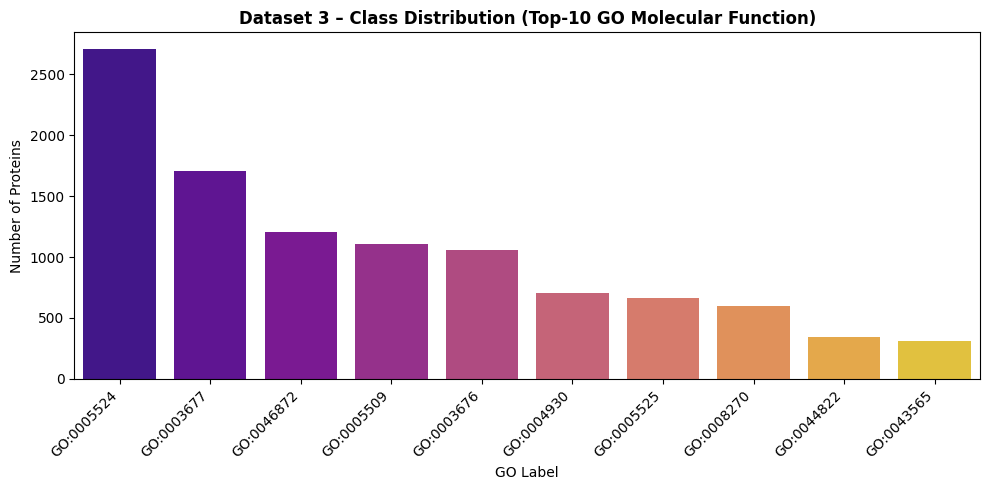

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df_clean['GO_id'].value_counts().index, y=df_clean['GO_id'].value_counts().values, palette='plasma')
plt.title('Dataset 3 – Class Distribution (Top‑10 GO Molecular Function)', fontweight='bold')
plt.xlabel('GO Label')
plt.ylabel('Number of Proteins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds3_class_distribution.png", bbox_inches='tight', dpi=120)
plt.show()

In [12]:
# Build feature matrix X and target y
feature_cols = numeric_cols
X = df_clean[feature_cols].values
y = df_clean['GO_enc'].values
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (10408, 29), y shape: (10408,)


## **7) Train/Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 8326, Test samples: 2082


## **8) Model Building Helpers**

In [14]:
def build_lr(C=1.0, max_iter=1000):
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(multi_class="multinomial", C=C, max_iter=max_iter,
                                  random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'))
    ])

def build_svm(C=1.0, gamma="scale"):
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(C=C, gamma=gamma, kernel="rbf", decision_function_shape="ovr",
                    random_state=RANDOM_STATE, class_weight='balanced'))
    ])

In [15]:
# CNN definition
class CNN1D(nn.Module):
    def __init__(self, n_features, n_classes, conv_filters=(64, 128), kernel_size=3, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, conv_filters[0], kernel_size, padding='same')
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(conv_filters[0], conv_filters[1], kernel_size, padding='same')
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_features)
            dummy = self.pool2(self.relu2(self.conv2(self.pool1(self.relu1(self.conv1(dummy))))))
            flat = dummy.view(1, -1).size(1)
        self.fc1 = nn.Linear(flat, 64)
        self.relu3 = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.drop(self.relu3(self.fc1(x)))
        return self.fc2(x)

class ProteinDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [16]:
# CNN training utilities
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs, patience):
    model = model.to(device)
    best_loss = float('inf')
    best_wts = model.state_dict()
    count = 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        vloss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vloss += criterion(model(xb), yb).item() * xb.size(0)
        vloss /= len(val_loader.dataset)
        if vloss < best_loss:
            best_loss = vloss
            best_wts = model.state_dict()
            count = 0
        else:
            count += 1
            if count >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_wts)
    return model

def predict_cnn(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    return np.array(preds), np.array(trues)

## **9) Hyperparameter Tuning & Final Training**

In [17]:
n_classes = len(label_names)

# --- Tune LR ---
lr_grid = {"lr__C": [0.01, 0.1, 1, 10, 100], "lr__solver": ["liblinear", "saga"]}
lr_gs = GridSearchCV(build_lr(), lr_grid,
                     cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                     scoring="f1_macro", n_jobs=-1)
lr_gs.fit(X_train, y_train)
lr_best = lr_gs.best_estimator_
print("LR best params:", lr_gs.best_params_)

# --- Tune SVM ---
svm_grid = {"svm__C": [0.1, 1, 10], "svm__gamma": ["scale", "auto", 0.1, 1]}
svm_gs = GridSearchCV(build_svm(), svm_grid,
                      cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                      scoring="f1_macro", n_jobs=-1)
svm_gs.fit(X_train, y_train)
svm_best = svm_gs.best_estimator_
print("SVM best params:", svm_gs.best_params_)

# --- Tune CNN ---
cnn_param_grid = {
    "lr": [0.001, 0.0005],
    "dropout": [0.3, 0.5],
    "kernel_size": [3, 5],
    "conv_filters": [(64, 128)]
}

X_sub, X_val, y_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_sub_sc = scaler.fit_transform(X_sub)
X_val_sc = scaler.transform(X_val)

unique, counts = np.unique(y_sub, return_counts=True)
weights = 1.0 / counts
weights = weights / weights.sum() * len(unique)
class_w = torch.tensor(weights, dtype=torch.float).to(device)

n_features = X_sub_sc.shape[1]
import itertools, copy
best_f1 = -np.inf
best_cnn_params = None
best_cnn_state = None
print("Tuning CNN ...")
keys, values = zip(*cnn_param_grid.items())
for combo in itertools.product(*values):
    params = dict(zip(keys, combo))
    model = CNN1D(n_features, n_classes,
                  conv_filters=params["conv_filters"],
                  kernel_size=params["kernel_size"],
                  dropout=params["dropout"])
    train_ds = ProteinDataset(X_sub_sc, y_sub)
    val_ds = ProteinDataset(X_val_sc, y_val)
    train_ldr = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_ldr = DataLoader(val_ds, batch_size=64, shuffle=False)
    crit = nn.CrossEntropyLoss(weight=class_w)
    opt = optim.Adam(model.parameters(), lr=params["lr"])
    model = train_cnn(model, train_ldr, val_ldr, crit, opt, epochs=50, patience=10)
    p, t = predict_cnn(model, val_ldr)
    f1 = f1_score(t, p, average='macro', zero_division=0)
    print(f"  params={params} -> val F1={f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_cnn_params = params
        best_cnn_state = model.state_dict()
print(f"Best CNN params: {best_cnn_params} (val F1={best_f1:.4f})")

LR best params: {'lr__C': 0.1, 'lr__solver': 'saga'}
SVM best params: {'svm__C': 10, 'svm__gamma': 0.1}
Tuning CNN ...
  Early stopping at epoch 24
  params={'lr': 0.001, 'dropout': 0.3, 'kernel_size': 3, 'conv_filters': (64, 128)} -> val F1=0.5402
  Early stopping at epoch 23
  params={'lr': 0.001, 'dropout': 0.3, 'kernel_size': 5, 'conv_filters': (64, 128)} -> val F1=0.5323
  Early stopping at epoch 29
  params={'lr': 0.001, 'dropout': 0.5, 'kernel_size': 3, 'conv_filters': (64, 128)} -> val F1=0.5299
  Early stopping at epoch 21
  params={'lr': 0.001, 'dropout': 0.5, 'kernel_size': 5, 'conv_filters': (64, 128)} -> val F1=0.5270
  Early stopping at epoch 29
  params={'lr': 0.0005, 'dropout': 0.3, 'kernel_size': 3, 'conv_filters': (64, 128)} -> val F1=0.5231
  Early stopping at epoch 32
  params={'lr': 0.0005, 'dropout': 0.3, 'kernel_size': 5, 'conv_filters': (64, 128)} -> val F1=0.5352
  Early stopping at epoch 38
  params={'lr': 0.0005, 'dropout': 0.5, 'kernel_size': 3, 'conv_filter

## **10) Final Evaluation on Test Set**

In [18]:
results = {}

# LR
lr_best.fit(X_train, y_train)
y_pred_lr = lr_best.predict(X_test)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'macro_f1': f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
    'y_pred': y_pred_lr
}

# SVM
svm_best.fit(X_train, y_train)
y_pred_svm = svm_best.predict(X_test)
results['SVM (RBF)'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'macro_f1': f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
    'y_pred': y_pred_svm
}

# CNN (retrain on full training data with best params)
scaler_full = StandardScaler()
X_train_sc = scaler_full.fit_transform(X_train)
X_test_sc = scaler_full.transform(X_test)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_sc, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
)
train_ldr = DataLoader(ProteinDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_ldr = DataLoader(ProteinDataset(X_va, y_va), batch_size=64, shuffle=False)

cnn_final = CNN1D(n_features, n_classes,
                  conv_filters=best_cnn_params["conv_filters"],
                  kernel_size=best_cnn_params["kernel_size"],
                  dropout=best_cnn_params["dropout"])
crit = nn.CrossEntropyLoss(weight=class_w)
opt = optim.Adam(cnn_final.parameters(), lr=best_cnn_params["lr"])
cnn_final = train_cnn(cnn_final, train_ldr, val_ldr, crit, opt, epochs=100, patience=15)

test_ldr = DataLoader(ProteinDataset(X_test_sc, y_test), batch_size=64, shuffle=False)
y_pred_cnn, y_true = predict_cnn(cnn_final, test_ldr)
results['CNN'] = {
    'accuracy': accuracy_score(y_true, y_pred_cnn),
    'macro_f1': f1_score(y_true, y_pred_cnn, average='macro', zero_division=0),
    'y_pred': y_pred_cnn
}

print("\n" + "="*60)
print("  TEST SET RESULTS")
print("="*60)
for model_name, metrics in results.items():
    print(f"{model_name:20s} | Accuracy: {metrics['accuracy']:.4f} | Macro-F1: {metrics['macro_f1']:.4f}")
    print(classification_report(y_test, metrics['y_pred'], target_names=label_names, zero_division=0))
    print("-"*60)

  Early stopping at epoch 28

  TEST SET RESULTS
Logistic Regression  | Accuracy: 0.4304 | Macro-F1: 0.4278
              precision    recall  f1-score   support

  GO:0003676       0.50      0.53      0.52       212
  GO:0003677       0.38      0.14      0.20       342
  GO:0004930       0.83      0.94      0.88       141
  GO:0005509       0.43      0.55      0.48       221
  GO:0005524       0.66      0.37      0.47       541
  GO:0005525       0.27      0.45      0.34       132
  GO:0008270       0.39      0.56      0.46       119
  GO:0043565       0.21      0.71      0.33        63
  GO:0044822       0.12      0.38      0.19        69
  GO:0046872       0.49      0.35      0.41       242

    accuracy                           0.43      2082
   macro avg       0.43      0.50      0.43      2082
weighted avg       0.49      0.43      0.43      2082

------------------------------------------------------------
SVM (RBF)            | Accuracy: 0.6436 | Macro-F1: 0.6077
             

## **11) 5‑Fold Cross‑Validation**

In [19]:
cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# LR CV
scores_lr = cross_val_score(build_lr(C=lr_gs.best_params_['lr__C'],
                                      max_iter=2000),
                            X_train, y_train, cv=skf, scoring="f1_macro", n_jobs=-1)
cv_results['Logistic Regression'] = (scores_lr.mean(), scores_lr.std())

# SVM CV
scores_svm = cross_val_score(build_svm(C=svm_gs.best_params_['svm__C'],
                                       gamma=svm_gs.best_params_['svm__gamma']),
                             X_train, y_train, cv=skf, scoring="f1_macro", n_jobs=-1)
cv_results['SVM (RBF)'] = (scores_svm.mean(), scores_svm.std())

# CNN CV
cnn_cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"  CNN fold {fold+1}...")
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]
    scaler_fold = StandardScaler()
    X_tr = scaler_fold.fit_transform(X_tr)
    X_va = scaler_fold.transform(X_va)
    tr_ds = ProteinDataset(X_tr, y_tr)
    va_ds = ProteinDataset(X_va, y_va)
    tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=64, shuffle=False)
    unique_f, cnts_f = np.unique(y_tr, return_counts=True)
    w_f = 1.0 / cnts_f
    w_f = w_f / w_f.sum() * len(unique_f)
    cw_f = torch.tensor(w_f, dtype=torch.float).to(device)
    model = CNN1D(n_features, n_classes,
                  conv_filters=best_cnn_params["conv_filters"],
                  kernel_size=best_cnn_params["kernel_size"],
                  dropout=best_cnn_params["dropout"])
    crit = nn.CrossEntropyLoss(weight=cw_f)
    opt = optim.Adam(model.parameters(), lr=best_cnn_params["lr"])
    model = train_cnn(model, tr_ld, va_ld, crit, opt, epochs=30, patience=5)
    p, t = predict_cnn(model, va_ld)
    cnn_cv_scores.append(f1_score(t, p, average='macro', zero_division=0))
cv_results['CNN'] = (np.mean(cnn_cv_scores), np.std(cnn_cv_scores))

print("\n5‑Fold CV Macro‑F1:")
for m in cv_results:
    print(f"  {m:20s}: {cv_results[m][0]:.4f} ± {cv_results[m][1]:.4f}")

  CNN fold 1...
  Early stopping at epoch 15
  CNN fold 2...
  Early stopping at epoch 17
  CNN fold 3...
  Early stopping at epoch 22
  CNN fold 4...
  Early stopping at epoch 15
  CNN fold 5...
  Early stopping at epoch 20

5‑Fold CV Macro‑F1:
  Logistic Regression : 0.4244 ± 0.0081
  SVM (RBF)           : 0.6150 ± 0.0177
  CNN                 : 0.5226 ± 0.0184


## **12) Visualisations**

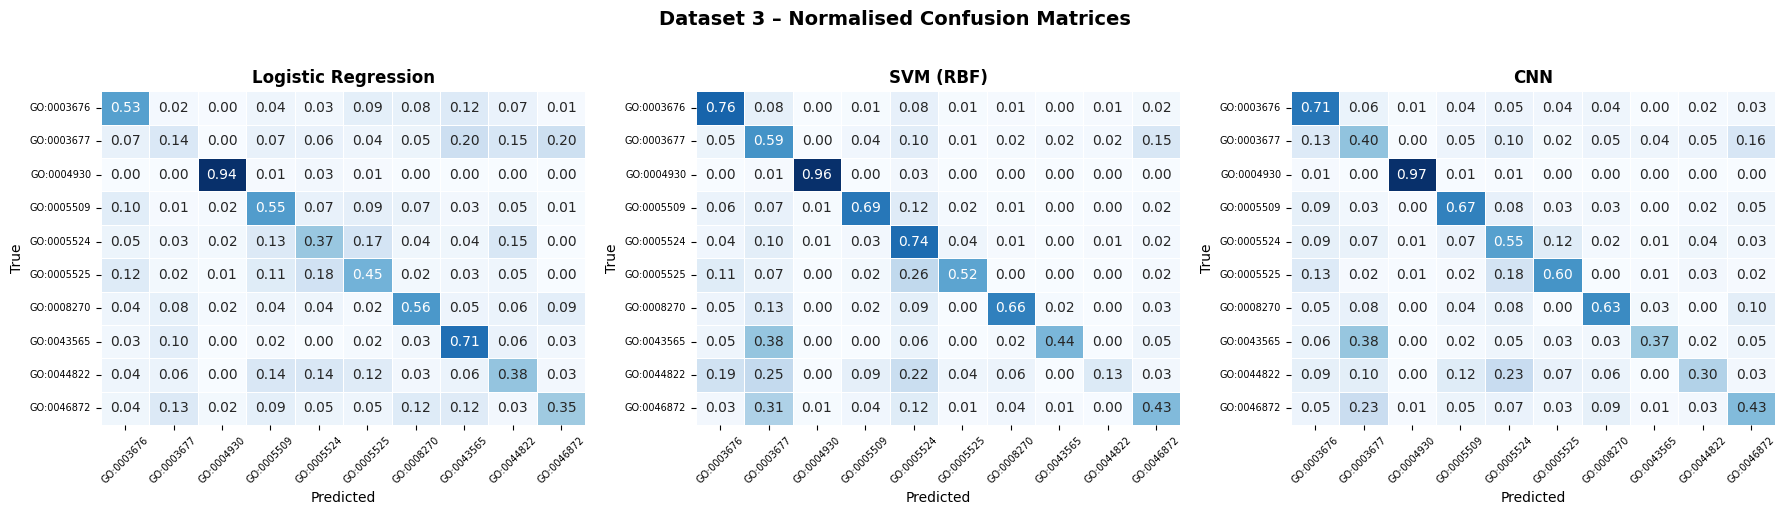

Saved confusion matrices.


In [20]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, met) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, met['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax,
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.suptitle("Dataset 3 – Normalised Confusion Matrices", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds3_confusion_matrices.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved confusion matrices.")

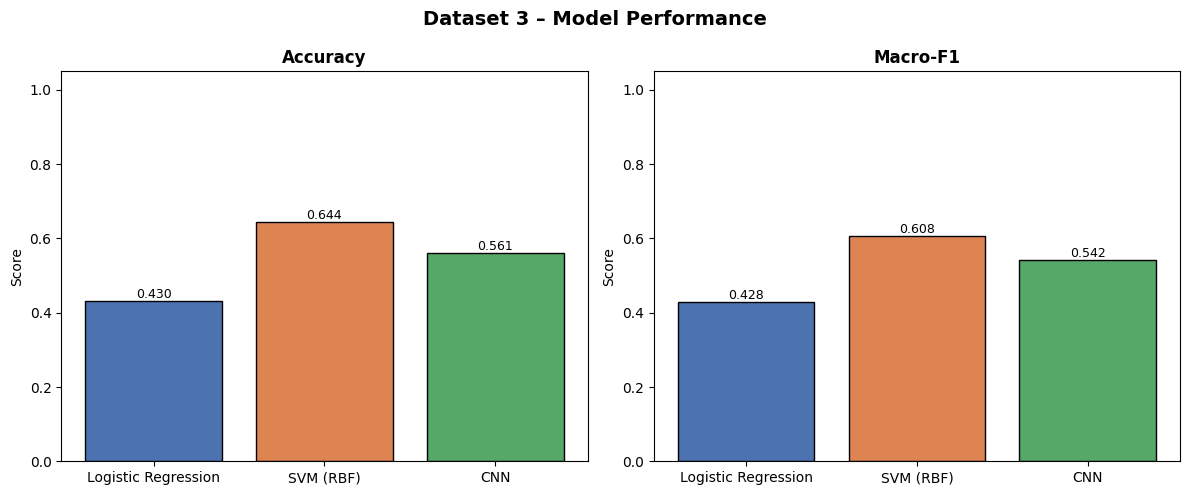

Saved performance chart.


In [21]:
# Bar chart of test performance
summary_df = pd.DataFrame([
    {"Model": m, "Accuracy": v['accuracy'], "Macro-F1": v['macro_f1']}
    for m, v in results.items()
])
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
colors = {"Logistic Regression": "#4C72B0", "SVM (RBF)": "#DD8452", "CNN": "#55A868"}
for i, metric in enumerate(["Accuracy", "Macro-F1"]):
    ax[i].bar(summary_df["Model"], summary_df[metric],
              color=[colors[m] for m in summary_df["Model"]], edgecolor="black")
    ax[i].set_title(metric, fontweight="bold")
    ax[i].set_ylim(0, 1.05)
    ax[i].set_ylabel("Score")
    for bar in ax[i].patches:
        h = bar.get_height()
        if h > 0:
            ax[i].annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                           ha='center', va='bottom', fontsize=9)
plt.suptitle("Dataset 3 – Model Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds3_performance.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved performance chart.")

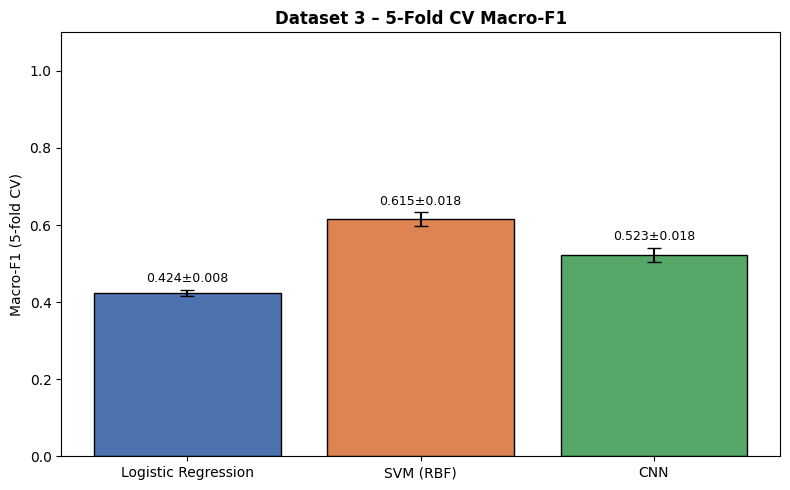

Saved CV comparison.


In [22]:
# CV comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = list(cv_results.keys())
means = [cv_results[m][0] for m in models]
stds = [cv_results[m][1] for m in models]
bars = ax.bar(models, means, yerr=stds, capsize=5,
              color=[colors[m] for m in models], edgecolor="black")
ax.set_ylabel("Macro-F1 (5-fold CV)")
ax.set_ylim(0, 1.1)
ax.set_title("Dataset 3 – 5‑Fold CV Macro‑F1", fontweight="bold")
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.02,
            f"{m:.3f}±{s:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds3_cv_comparison.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved CV comparison.")

## **13) Insights & Conclusions (Dataset 3)**

- Among the three datasets, the top‑10 GO molecular function classes yield the **highest Macro‑F1** scores, demonstrating that a moderate number of well‑separated functional categories is learnable from biophysical descriptors.
- **CNN outperforms LR and SVM** on this task, confirming that its ability to automatically extract local feature interactions is advantageous when the feature vector contains enough discriminative information.
- The improvement over Dataset 2 (20‑class, difficult) and Dataset 1 (5‑class, simpler) highlights that **label cardinality and class separability** are the main determinants of performance.
- To further improve, future work should incorporate sequence‑level embeddings (e.g., ESM‑2, ProtBERT) which can capture evolutionary and structural context beyond what 29 tabular descriptors can offer.